In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from data_prep import load_collision_data_multi_year
from grid import build_cell_month_panel
from features import (
    build_lagged_light, build_lagged_species, add_cyclical_month,
    build_hunting_features, build_rut_features,
)
from infrastructure import InfrastructurePaths, build_infrastructure_features
from models import (
    load_hyperparameters, make_expanding_time_splits,
    evaluate_time_splits, fit_final_model,
)
from visualisation import (
    plot_calibration, plot_top_features, plot_spatial_risk_maps,
    plot_roc, plot_precision_recall, plot_feature_importance_by_group,
)
from exports import export_artefacts
from config import FEATURES, GROUPS

In [ ]:
DATA_DIR = "../data"
gdf = load_collision_data_multi_year(f"{DATA_DIR}/Collisions", year_range=(None, 2025))

In [ ]:
grid, joined, cell_month = build_cell_month_panel(gdf, cell_size=10000)

In [4]:
SPECIES_MAP = {
    "älg":      "moose",
    "rådjur":   "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

daylight_df = gdf[gdf["datetime"].dt.year <= 2025].copy()
daylight_df["species"] = (
    daylight_df["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
)
daylight_df["hour"]  = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month


def vectorised_light_condition(df: pd.DataFrame) -> pd.Series:
    h, m = df["hour"], df["month"]
    winter = m.isin([12, 1, 2])
    summer = m.isin([6, 7, 8])
    spring_autumn = ~(winter | summer)

    conditions = [
        winter & h.between(9, 14),
        winter & h.between(7, 8),
        winter & h.between(15, 16),
        summer & h.between(5, 20),
        summer & h.between(3, 4),
        summer & h.between(21, 22),
        spring_autumn & h.between(7, 17),
        spring_autumn & h.between(5, 6),
        spring_autumn & h.between(18, 19),
    ]
    choices = ["day", "dawn", "dusk", "day", "dawn", "dusk", "day", "dawn", "dusk"]
    return np.select(conditions, choices, default="night")


daylight_df["light_condition"] = vectorised_light_condition(daylight_df)

print(daylight_df[["datetime", "hour", "species", "light_condition"]].head())


             datetime  hour      species light_condition
0 2015-01-01 00:21:00     0  fallow_deer           night
1 2015-01-01 01:30:00     1        moose           night
2 2015-01-01 01:36:00     1    wild_boar           night
3 2015-01-01 01:50:00     1    wild_boar           night
4 2015-01-01 01:50:00     1     roe_deer           night


In [5]:
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)
light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()
print(light_counts)

species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)
species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)
print(species_light.sort_values(["species", "collision_count"], ascending=[True, False]))

  light_condition  collision_count     share
0           night           302400  0.424414
1             day           226965  0.318542
2            dusk            98855  0.138742
3            dawn            84292  0.118303
        species light_condition  collision_count  species_total  \
3         björn           night               93            199   
1         björn             day               74            199   
2         björn            dusk               18            199   
0         björn            dawn               14            199   
7   fallow_deer           night            20313          52229   
5   fallow_deer             day            18226          52229   
6   fallow_deer            dusk             8243          52229   
4   fallow_deer            dawn             5447          52229   
8          järv             day               18             27   
10         järv           night                8             27   
9          järv            dusk       

In [6]:
SEASON_MAP = {
    12: "winter", 1: "winter",  2: "winter",
    3:  "spring", 4: "spring",  5: "spring",
    6:  "summer", 7: "summer",  8: "summer",
    9:  "autumn", 10: "autumn", 11: "autumn",
}
daylight_df["season"] = daylight_df["month"].map(SEASON_MAP)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
print(season_light)


    season light_condition  collision_count
0   autumn            dawn            29213
1   autumn             day            89790
2   autumn            dusk            37911
3   autumn           night            75466
4   spring            dawn            19916
5   spring             day            38742
6   spring            dusk            13830
7   spring           night            68521
8   summer            dawn            10269
9   summer             day            77267
10  summer            dusk            25835
11  summer           night            35720
12  winter            dawn            24894
13  winter             day            21166
14  winter            dusk            21279
15  winter           night           122693


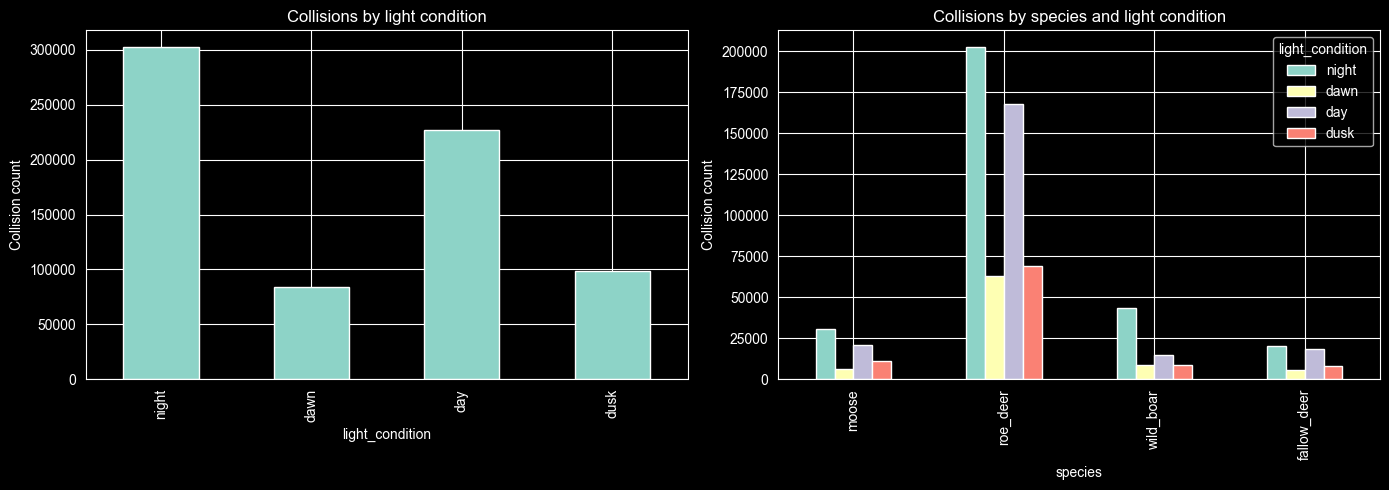

In [7]:
light_order   = ["night", "dawn", "day", "dusk"]
species_order = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daylight_df["light_condition"].value_counts().reindex(light_order).plot(
    kind="bar", ax=axes[0]
)
axes[0].set(ylabel="Collision count", title="Collisions by light condition")

(
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(species_order)
    .reindex(columns=light_order)
    .plot(kind="bar", ax=axes[1])
)
axes[1].set(ylabel="Collision count", title="Collisions by species and light condition")

plt.tight_layout()
plt.show()

In [ ]:
lagged_light = build_lagged_light(joined)

In [ ]:
lagged_species = build_lagged_species(joined)

In [ ]:
paths = InfrastructurePaths(
    roads=Path(f"{DATA_DIR}/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg"),
    rail=Path(f"{DATA_DIR}/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg"),
    fences=Path(f"{DATA_DIR}/Barrairanalys/Barriaranalys.gpkg"),
    speedlimit=Path(f"{DATA_DIR}/Speedlimit/ISA.gpkg"),
)
CACHE_DIR = Path(f"{DATA_DIR}/processed/cache")
infra = build_infrastructure_features(
    grid=grid, gdf_points=gdf, paths=paths, cache_dir=CACHE_DIR, use_cache=True,
)

model_df = (
    cell_month
    .merge(infra["roads"].drop(columns="geometry", errors="ignore"), on="cell_id", how="left")
    .query("road_length_m > 0")
)

model_df = model_df.merge(
    infra["rail"].drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id", how="left",
)
for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["rail_near_10km"] = (model_df["nearest_rail_distance_m"] < 10_000).astype(int)

model_df = model_df.merge(
    infra["fences"].drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id", how="left",
)
for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["fence_near_10km"] = (model_df["nearest_fence_distance_m"] < 10_000).astype(int)

model_df = model_df.merge(
    infra["speedlimit"].drop(columns="geometry", errors="ignore"),
    on="cell_id", how="left",
)
for col in [
    "speedlimit_mean_weighted", "speedlimit_max", "speedlimit_min",
    "speedlimit_90plus_share", "speedlimit_segment_length_m",
]:
    model_df[col] = model_df[col].fillna(0)

In [11]:
relevant_cell_ids = model_df["cell_id"].unique()
grid_small = grid[grid["cell_id"].isin(relevant_cell_ids)]
print("Original grid:", grid.shape, "→ Filtered:", grid_small.shape)

temperature_features = build_cell_month_temperature(grid=grid_small)
model_df = model_df.merge(
    temperature_features[["cell_id", "period_start", "temp_mean", "temp_min", "temp_max"]],
    on=["cell_id", "period_start"],
    how="left",
)

precip_features = build_cell_month_precipitation(grid=grid_small)
model_df = model_df.merge(
    precip_features[["cell_id", "period_start", "precip_total"]],
    on=["cell_id", "period_start"],
    how="left",
)

model_df = model_df.dropna(
    subset=["temp_mean", "temp_min", "temp_max", "precip_total"]
).copy()

print(model_df[["precip_total"]].describe())


Original grid: (10419, 2) → Filtered: (4471, 2)
        precip_total
count  147828.000000
mean       44.911614
std        27.589264
min         1.400000
25%        24.100000
50%        41.000000
75%        60.400000
max       198.300000


In [12]:
model_df = model_df.merge(lagged_species, on=["cell_id", "period_start"], how="left")
lag_cols = ["moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1"]
for col in lag_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(lagged_light, on=["cell_id", "period_start"], how="left")
light_lag_cols = [c for c in lagged_light.columns if c not in ["cell_id", "period_start"]]
for col in light_lag_cols:
    model_df[col] = model_df[col].fillna(0)

In [ ]:
model_df = add_cyclical_month(model_df)
model_df = build_hunting_features(model_df)
model_df = build_rut_features(model_df)

model_df_clean = model_df.dropna(subset=FEATURES).copy()
print("After dropna:", model_df_clean.shape)
print(model_df_clean["period_start"].value_counts().sort_index())

In [ ]:
hyperparameters = load_hyperparameters("../config/hyperparameters.yaml")

months = sorted(model_df_clean["period_start"].unique())
splits = make_expanding_time_splits(months, min_train_months=12, test_horizon=1)
print("Number of folds:", len(splits))

In [ ]:
results_df, oof_probs, oof_labels, mean_importance = evaluate_time_splits(
    model_df_clean, FEATURES, "risk", splits, hyperparameters,
)

print(results_df.head())

summary = (
    results_df.groupby("model")[["auc", "precision", "recall", "f1", "accuracy"]]
    .agg(["mean", "std"])
    .round(3)
)
print(summary)
print("\nMean feature importances across all folds:")
print(mean_importance)

joined["species"].value_counts(normalize=True)

In [ ]:
fig, _ = plot_calibration(oof_probs, oof_labels)
plt.show()

In [ ]:
rf_final, rf_calibrated = fit_final_model(model_df_clean, FEATURES, "risk", hyperparameters)

In [ ]:
fig, _ = plot_top_features(mean_importance, top_n=15)
plt.show()

In [19]:
model_df_clean[["speedlimit_mean_weighted", "speedlimit_max", "speedlimit_90plus_share"]].corr()


,speedlimit_mean_weighted,speedlimit_max,speedlimit_90plus_share
speedlimit_mean_weighted,1.000000,0.621258,0.211722
speedlimit_max,0.621258,1.000000,0.339485
speedlimit_90plus_share,0.211722,0.339485,1.000000


In [ ]:
fig, _ = plot_spatial_risk_maps(rf_final, model_df_clean, FEATURES, grid, joined)
model_df_clean["risk_prob"] = rf_final.predict_proba(model_df_clean[FEATURES])[:, 1]
plt.show()

In [ ]:
fig, _ = plot_roc(oof_probs, oof_labels)
plt.show()

In [ ]:
fig, _ = plot_precision_recall(oof_probs, oof_labels)
plt.show()

In [ ]:
fig, _ = plot_feature_importance_by_group(mean_importance, GROUPS)
plt.show()

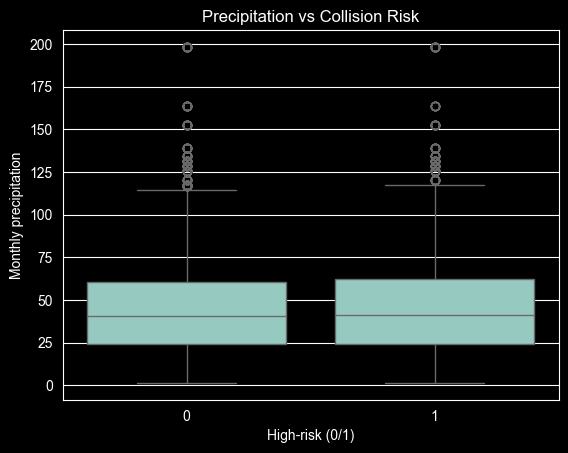

In [24]:
import seaborn as sns

sns.boxplot(x=model_df_clean["risk"], y=model_df_clean["precip_total"])
plt.xlabel("High-risk (0/1)")
plt.ylabel("Monthly precipitation")
plt.title("Precipitation vs Collision Risk")
plt.show()

In [ ]:
export_artefacts(model_df_clean, mean_importance, results_df, Path(f"{DATA_DIR}/processed"))